# iprPy grain_boundary_grip calculation

In [1]:
# Standard library imports
import datetime
from copy import deepcopy

# http://www.numpy.org/
import numpy as np

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-07-08 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('grain_boundary_grip')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# grain_boundary_grip calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The grain_boundary_grip calculation style constructs and relaxes a grain boundary structure according to the grand-canonical interface predictor (GRIP) algorithm.

### Version notes

- v0.??.?: Calculation method created by combining and generalizing the previous grain_boundary_search and grain_boundary_bcc methods.
- v0.11.?: Calculation method updated to be consistent with the new grain_boundary_grip method by using small non-periodic atomic configurations.
- v0.12.0: Method updated to support the LAMMPS library interface.
  
### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)



## Method and Theory

### GRIP grain boundary relaxations

This method uses the grand canonical interface predictor (GRIP) algorithm to construct a grain boundary configuration for a given crystal and orientation, and then relaxes the configuration. To explore a wide range of configurations, the alignment of the two grains, numbers and positions of atoms at the grain boundary, and relaxation settings are all randomly selected. Repeatedly running the calculation allows for many relaxations to be sampled which can reveal new low energy configurations, and the dependence of the grain boundary configuration on the number of vacancies/interstitials at the boundary.

See the atomman.defect.GRIP documentation for more details on the random values...

### System design

All grain boundary configurations are periodic along the two shortest in-plane lattice vectors and non-periodic perpendicular to the grain boundary plane. The atoms near the non-periodic free surface are constrained: all atoms in one boundary are held fixed, and all atoms in the other boundary move as a rigid block. The widths of the relaxation and boundary regions depend on the relaxation stage. For the MD stage, only the atoms closest to the grain boundary (typically 10 Angstroms into each grain) are allowed to relax, while the remaining atoms are treated as the surface boundaries.  For the energy/force minimization stage, the active region is doubled (40 Angstroms total, 20 in each grain). The total width of the system is selected to be such that the surface boundary regions are always at least 10 Angstroms thick, thus the total width is > 60 Angstroms, 30 Angstroms per grain.


## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "grain_boundary_grip.py"

# Python script created by Lucas Hale

# Standard library imports
from pathlib import Path
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np
import numpy.typing as npt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat, lammps
from atomman.lammps import LAMMPS, LAMMPSobj
from atomman.defect import GrainBoundary, GRIP

def grain_boundary_grip(lammps_command: Union[str, LAMMPSobj],
                        ucell: am.System,
                        potential: lammpspotential,
                        uvws1: npt.ArrayLike,
                        uvws2: npt.ArrayLike,
                        potential_energy: float,
                        mpi_command: Optional[str] = None,
                        conventional_setting: str = 'p',
                        cutboxvector: str = 'c',
                        gbwidth: unitfloat = '10 angstrom',
                        bufferwidth: unitfloat = '10 angstrom',
                        boundarywidth: unitfloat = '10 angstrom',
                        etol: float = 1e-15,
                        ftol: unitfloat = '1e-15 eV/atom',
                        maxiter: int = 100000,
                        maxeval: int = 1000000,
                        dmax: unitfloat = '0.01 angstrom',
                        grip: Optional[GRIP] = None,
                        randomseed: Optional[int] = None,
                        verbose: bool = False,
                        usefiles: bool = False,
                        **kwargs):
    """
    Creates a grain boundary using the GRIP algorithm, relaxes it using both
    MD integrations and minimization, and evaluates the grain boundary energy.

    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    ucell : atomman.System
        The crystal unit cell to use as the basis of the grain boundary
        configurations.
    potential : PotentialLAMMPS or PotentialLAMMPSKIM
        The LAMMPS implemented potential to use.
    uvws1 : array-like object
        The Miller(-Bravais) crystal vectors associated with rotating ucell to
        form the 'top' grain.
    uvws2 : array-like object
        The Miller(-Bravais) crystal vectors associated with rotating ucell to
        form the 'bottom' grain.
    potential_energy : float, optional
        The per-atom potential energy of the bulk crystal to use for the grain
        boundary energy calculation.  This is currently limited to a single
        value so it only works with elemental systems.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel.  If not given, LAMMPS
        will run serially.
    conventional_setting : str, optional
        Specifies the cell setting for ucell if it is a non-primitive unit cell.
        This is used in generating the boundary configuration and determining
        the smallest out-of-plane lattice vector component.
    cutboxvector : str, optional
        Indicates which of the three system box vectors, 'a', 'b', or 'c', is
        out-of-plane with the grain boundary (default is 'c').  
    gbwidth : float, optional
        The width of the grain boundary region taken as the distance into both
        crystals from the grain boundary plane.  This region will be relaxed
        during both the MD and minimization stages.  Note that the region
        itself will be twice as thick as gbwidth as it is applied to both
        crystals independently.  Default value is 10 angstroms.
    bufferwidth : float, optional
        The width of the buffer regions that separate the grain boundary
        region from the fixed atom surface boundary regions.  The buffer
        regions will not be relaxed during the MD stage, but will be relaxed
        during the minimization stage. Default value is 10 angstroms.
 

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 4'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial unit cell system

- __ucell__ is an atomman.System representing a fundamental unit cell of the system (required).  Here, this is generated by loading the relaxed fcc crystal for the potential from the database.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Create ucell by loading prototype record
ucell = am.load('crystal', potential=potential, family='A1--Cu--fcc')

print(ucell)

Multiple matching record retrieved from remote
#  family               symbols  alat    Ecoh    method  standing
 1 A1--Cu--fcc          Ni        3.5200 -4.4500 dynamic good
 2 A1--Cu--fcc          Ni        7.3760  0.0119 dynamic good


Please select one: 1


avect =  [ 3.520,  0.000,  0.000]
bvect =  [ 0.000,  3.520,  0.000]
cvect =  [ 0.000,  0.000,  3.520]
origin = [ 0.000,  0.000,  0.000]
natoms = 4
natypes = 1
symbols = ('Ni',)
pbc = [ True  True  True]
per-atom properties = ['atype', 'pos']
     id |   atype |  pos[0] |  pos[1] |  pos[2]
      0 |       1 |   0.000 |   0.000 |   0.000
      1 |       1 |   0.000 |   1.760 |   1.760
      2 |       1 |   1.760 |   0.000 |   1.760
      3 |       1 |   1.760 |   1.760 |   0.000


### 3.4 Defect parameters

- __uvws1__: The three miller vectors with respect to the given unit cell that specify how the top grain is to be oriented.
- __uvws2__: The three miller vectors with respect to the given unit cell that specify how the bottom grain is to be oriented.
- __conventional_setting__: If the given unit cell is a conventional cell, specifying this allows for the algorithms to find lattice vectors with fractional coordinates.  Recognized values are 'p' primitive (default), 'f' face-centered, 'i' body-centered, 'a', 'b', 'c' side-centered. 
- __cutboxvector__: Indicates which box vector 'a', 'b', or 'c' the grain boundary plane intersects. Default value is 'c'.

In [9]:
# Grain orientations for fcc <100> symmetric tilt with 53.13 misorientation
uvws1 = np.array([[ 0, 0, 1], [ 2, 1, 0], [-1, 2, 0]])            
uvws2 = np.array([[ 0, 0, 1], [ 2,-1, 0], [ 1, 2, 0]])
conventional_setting = 'f'
cutboxvector = 'c'

### 3.5. GRIP settings

- __randomseed__ is the random number generator seed with the GRIP algorithm to generate the various random GRIP algorithm settings.  Repeated GRIP relaxations can be performed by changing only the randomseed.  The default value of None will randomly select a random seed value.
- __grip__ is an atomman.defect.GRIP object that manages the selection of the various random GRIP algorithm settings. The class is defined by specifying the sample ranges and sampling styles for the random settings, and then it will select all values based on the given randomseed.
    - __temperature_min__ is the minimum temperature to include in the sampling.
    - __temperature_max__ is the maximum temperature to include in the sampling.
    - __temperature_delta__ is the spacing to use between possible temperature samples.  Default value is 100.
    - __temperature_sample_style__ is the sampling style to use for the temperature.  "uniform" will uniformly sample from the range provided and is the only currently supported style.
    - __shift_delta__ is the fractional spacing to use between possible in-plane shift samples. Default value is 0.05. Note shifts should range from 0 to 1.
    - __sizemult_min1__ is the minimum size multiplier to use for the first in-plane box vector. The multiplier to use will be selected between the min1 and max1 values inclusively.  Default value is 1.
    - __sizemult_max1__ is the maximum size multiplier to use for the first in-plane box vector. The multiplier to use will be selected between the min1 and max1 values inclusively. Default value is 3.
    - __sizemult_min2__ is the minimum size multiplier to use for the second in-plane box vector. The multiplier to use will be selected between the min2 and max2 values inclusively.  Default value is 1.
    - __sizemult_max2__ is the maximum size multiplier to use for the second in-plane box vector. The multiplier to use will be selected between the min2 and max2 values inclusively. Default value is 3.
    - __sizemult_sample_style__ indicates the sample style to use for the size multipliers. "exponential" (default) will place higher sample weights on smaller sizemults. "uniform" will equally sample from the sizemults range.
    - __runsteps_chance__ is a probability rate between 0 and 1 for if the MD relaxation will be performed: a value of 0 means MD is never done and a value of 1 means MD is always done.  Default value is 0.95 (5% chance of no MD).
    - __runsteps_min__ is the minimum runsteps value to include in the sampling. Default value is 5000.
    - __runsteps_max__ is the maximum runsteps value to include in the sampling. Default value is 500000.
    - __runsteps_delta__ is the spacing to use between possible runsteps samples. Default value is 1000.
    - __runsteps_sample_style__ is the sampling style to use for the runsteps. "uniform" will uniformly sample from the range provided. "exponential" (default) will weight smaller runsteps as being more likely.
    - __maxmult__ is the maximum size multiplier to use in searching for correspondence between the in-plane vectors of both grains.  Both grains will be searched up to this max so only one grain's multiplier is guaranteed to be maxmult or less.  Default value is 10.
    - __minwidth__ is the minimum width for both grains perpendicular to the grain boundary.  Default value is 30.
    - __delete_min__ is the minimum fraction of atoms to delete.  Default value is 0.0.
    - __delete_max__ is the maximum fraction of atoms to delete.  Default value is 1.0.
    - __perturb_width__ is the width from the grain boundary in each grain within which atoms will be perturbed.  Default value is 10.
    - __perturb_max1__ is the maximum atomic perturbations that will be applied to atoms in grain 1.  Default value is 0.3.
    - __perturb_max2__ is the maximum atomic perturbations that will be applied to atoms in grain 2.  Default value is 0.0.
    - __interstitial_min__ is the minimum number of interstitial sites to fill. Default value is 0.
    - __interstitial_max__ is the max number of interstitial sites to fill. Note that the actual max may be less if the number of atoms or the number of interstitial sites at the grain boundary are smaller.  Default value is 2.
    - __interstitial_width__: Only interstitial sites within the interstitial_width distance from the grain boundary will be considered for filling, and only atoms within 2*interstitial_width from the grain boundary will be considered for moving.  Default value is 1.5.
    - __interstitial_sample_style__ is the sampling weight to use for selection of the interstitial sites to fill.  If 'uniform' (default), all sites will have equal likelihood of being filled.  If 'volume', then the likelihood of sites being filled is weighted based on the site's volume. 

In [10]:
randomseed = 56

# Only temperature_min and temperature_max lack default values.
# All commented out values are the defaults.
grip = am.defect.GRIP(
    temperature_min = 300,
    temperature_max = 2000,
    #temperature_delta = 100,
    #temperature_sample_style = "uniform",
    #shift_delta = 0.05,
    #sizemult_min1 = 1,
    #sizemult_max1 = 3,
    #sizemult_min2 = 1,
    #sizemult_max2 = 3,
    #sizemult_sample_style = "exponential",
    #runsteps_chance = 0.95,
    #runsteps_min = 5000,
    #runsteps_max = 500000,
    #runsteps_delta = 1000,
    #runsteps_sample_style = "exponential",
    #maxmult = 10,
    #minwidth = 30,
    #delete_min = 0.0,
    #delete_max = 1.0,
    #perturb_width = 10,
    #perturb_max1 = 0.3,
    #perturb_max2 = 0.0,
    #interstitial_min = 0,
    #interstitial_max = 2,
    #interstitial_width = 1.5,
    #interstitial_sample_style = 'uniform',
)

### 3.6 Calculation-specific parameters

- __potential_energy__ is the per-atom potential energy of the bulk crystal to use for the grain boundary energy calculation.  This is currently limited to a single value so it only works with elemental systems.
- __gbwidth__ is the width of the region nearest the grain boundary where the atoms will be allowed to relax with both MD and minimization.  Note that this width is separately applied to both grains, so the total width of the relaxation region is twice this value.  Default value is 10 angstrom.
- __bufferwidth__ is the width of the region next to the gbwidth region where the atoms inside will be relaxed with the energy/force minimization but not with MD  Default value is 10 angstrom.
- __boundarywidth__ is the width to use for the constrained boundary regions outside of the relaxation regions.  Default value is 10 angstrom.
- __etol__ is the energy tolerance to use during the minimizations. This is unitless.
- __ftol__ is the force tolerance to use during the minimizations. This is in energy/length units.
- __maxiter__ is the maximum number of minimization iterations to use.
- __maxeval__ is the maximum number of minimization evaluations to use.
- __dmax__ is the largest distance that an atom is allowed to move during a minimization iteration. This is in length units.


In [11]:
potential_energy = -4.4500
gbwidth = 10
bufferwidth = 10
boundarywidth = 10
etol = 1e-8
ftol = uc.set_in_units(0.0, 'eV/angstrom')
maxiter = 10000
maxeval = 100000
dmax = uc.set_in_units(0.01, 'angstrom')

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [12]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.grain_boundary_grip.grain_boundary_grip'

In [13]:
results_dict = calculation.calc(lammps_command, ucell, potential,
                                uvws1, uvws2, potential_energy,
                                mpi_command = mpi_command,
                                conventional_setting = conventional_setting,
                                cutboxvector = cutboxvector,
                                gbwidth = gbwidth,
                                bufferwidth = bufferwidth,
                                boundarywidth = boundarywidth,
                                grip = grip,
                                randomseed = randomseed,
                                etol = etol,
                                ftol = ftol,
                                maxiter = maxiter,
                                maxeval = maxeval,
                                dmax = dmax)
print(results_dict.keys())

dict_keys(['grip', 'gb_energy', 'dumpfile_final', 'symbols_final'])


### 4.2. Report results

Values returned in the results_dict:

- **'grip'** (*atomman.defect.GRIP*) - The grip calculation settings object.  Can be used to view what relaxation settings were seleted.
- **'gb_energy'** (*float*) - The grain boundary energy for the relaxed configuration.
- **'dumpfile_final'** (*atomman.System*) - The name of the dump file associated wiht the relaxed configuration.
- **'symbols_final'** (*list*) - The element model symbos for the dump file.


In [14]:
energy_per_area_unit = 'eV/angstrom^2'

print('E_gb =', uc.get_in_units(results_dict['gb_energy'], energy_per_area_unit), energy_per_area_unit)

E_gb = 0.11218313893425394 eV/angstrom^2


In [15]:
# Show GRIP relaxation settings: inputs and selected values
grip.metadata()

{'name': 'grip-settings',
 'shift_delta': 0.05,
 'temperature_min': 300.0,
 'temperature_max': 2000.0,
 'temperature_delta': 100.0,
 'temperature_sample_style': 'uniform',
 'sizemult_min1': 1,
 'sizemult_max1': 3,
 'sizemult_min2': 1,
 'sizemult_max2': 3,
 'sizemult_sample_style': 'exponential',
 'runsteps_chance': 0.95,
 'runsteps_min': 5000,
 'runsteps_max': 500000,
 'runsteps_delta': 1000,
 'runsteps_sample_style': 'exponential',
 'maxmult': 10,
 'minwidth': 30.0,
 'delete_min': 0.0,
 'delete_max': 1.0,
 'perturb_width': 10.0,
 'perturb_max1': 0.3,
 'perturb_max2': 0.0,
 'interstitial_min': 0,
 'interstitial_max': 2,
 'interstitial_width': 1.5,
 'interstitial_sample_style': 'uniform',
 'randomseed': 56,
 'shift1': 0.35000000000000003,
 'shift2': 0.7000000000000001,
 'sizemult1': 1,
 'sizemult2': 3,
 'runsteps': 61000,
 'temperature': 800.0,
 'density': 0.7666666666666667,
 'ninterstitials': 2}

In [16]:
# Load dump file
gb_system = am.load('atom_dump', results_dict['dumpfile_final'],
                    symbols = results_dict['symbols_final'])

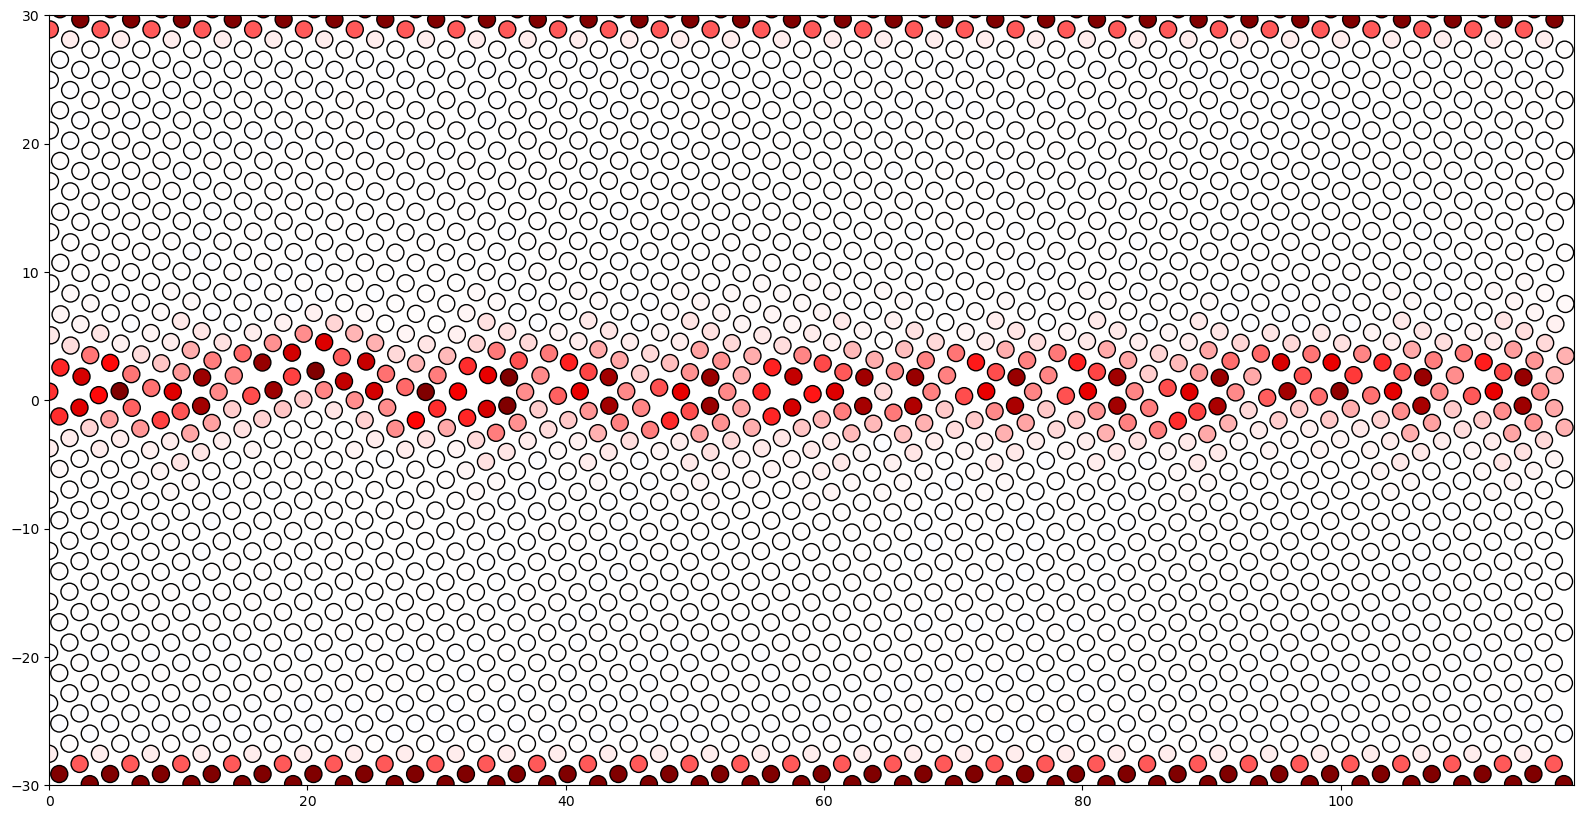

In [17]:
# Create projection plot along the <100> tilt axis

# Get system's original b lattice vector (a.k.a. ymax)
ymax = gb_system.box.b

# Wrap atoms, supersize and get y, z, and pe 
gb_system.wrap()
y = gb_system.atoms.pos[:, 1]
z = gb_system.atoms.pos[:, 2]
pe = gb_system.atoms.c_peatom

# Init figure with width scaled to ymax (height is 10 for 60 Angstroms)
fig = plt.figure(figsize=(ymax / 6, 10))  

plt.scatter(y, z, s=150, c=pe, vmin=potential_energy-0.5, vmax=potential_energy+0.5, cmap='seismic', edgecolors='k')
plt.xlim(0, ymax)
plt.ylim(-30, 30)

plt.show()

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [18]:
calculation.clean_files()